## Questions I'm Answering

1. **Category oversaturation vs. opportunity**: Which app categories are 
   packed with many apps competing for relatively few installs each, versus 
   categories with fewer apps but high installs per app?
2. **Does app size predict rating?** Do smaller, lighter apps get rated 
   better than large, heavy ones?
3. **Is there a pricing sweet spot?** Among paid apps, is there a price 
   range associated with better ratings, or does charging anything at all 
   correlate with lower satisfaction compared to free apps?
4. **Does time since last update affect ratings/installs?** Do apps that 
   haven't been updated recently show worse ratings or fewer installs than 
   actively maintained apps?
5. **Does content rating affect popularity?** Do "Teen" or "Mature 17+" 
   apps get meaningfully fewer installs than "Everyone"-rated apps?

In [114]:
#importing all necessary project libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#importing the csv file as a python dataframe
gps_data = pd.read_csv('../data/googleplaystore.csv')

## Initial Exploration: checking data types and structure before cleaning

##### Size of DataFrame, Data Info, Quick Look, and Basic Statistical Look

In [115]:
#(rows, columns) / size of the dataframe
gps_data.shape

(10841, 13)

In [116]:
# Quick look at each column, non-null count, datatype (default)
gps_data.info()

print("\n\n")

#Quick look at the sample/ first 5 rows of the rawdata
gps_data.head()

<class 'pandas.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  str    
 1   Category        10841 non-null  str    
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  str    
 4   Size            10841 non-null  str    
 5   Installs        10841 non-null  str    
 6   Type            10840 non-null  str    
 7   Price           10841 non-null  str    
 8   Content Rating  10840 non-null  str    
 9   Genres          10841 non-null  str    
 10  Last Updated    10841 non-null  str    
 11  Current Ver     10833 non-null  str    
 12  Android Ver     10838 non-null  str    
dtypes: float64(1), str(12)
memory usage: 1.1 MB





,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [117]:
# Data Frame's Rating column description
gps_data["Rating"].describe()
# =gps_data.describe()

count    9367.000000
mean        4.193338
std         0.537431
min         1.000000
25%         4.000000
50%         4.300000
75%         4.500000
max        19.000000
Name: Rating, dtype: float64

## Documenting what needs cleaning

In [118]:
# Checking the sum of each column's missing values/null values
gps_data.isnull().sum()

App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64

In [119]:
#Total missing data sum of the dataframe
gps_data.isnull().sum().sum()

np.int64(1487)

In [120]:
gps_data.dtypes #data types of each column

App                   str
Category              str
Rating            float64
Reviews               str
Size                  str
Installs              str
Type                  str
Price                 str
Content Rating        str
Genres                str
Last Updated          str
Current Ver           str
Android Ver           str
dtype: object

Detected mistakes on raw data:


<small>
All obvious detection/mistakes in the data:
    
-There are a  total of 1487 cells with missing data that have null values
   
-Numerical cells such as installs, price,reviews, and size are as string objects
    
We can conclude that without fixing these mistakes first that they are just text, and Pandas can't run average or sums on columns like reviews or installs yet.

</small>

## Finding the unique values for the columns that are irregular / wrong type

In [121]:
gps_data['Reviews'].unique()[:10]

<StringArray>
['159', '967', '87510', '215644', '167', '178', '36815', '13791', '121',
 '13880']
Length: 10, dtype: str

In [122]:
gps_data['Size'].unique()[:10]


<StringArray>
['19M', '14M', '8.7M', '25M', '2.8M', '5.6M', '29M', '33M', '3.1M', '28M']
Length: 10, dtype: str

In [123]:
gps_data['Installs'].unique()[:10]

<StringArray>
[     '10,000+',     '500,000+',   '5,000,000+',  '50,000,000+',
     '100,000+',      '50,000+',   '1,000,000+',  '10,000,000+',
       '5,000+', '100,000,000+']
Length: 10, dtype: str

In [124]:
gps_data['Price'].unique()[:10]

<StringArray>
[    '0', '$4.99', '$3.99', '$6.99', '$1.49', '$2.99', '$7.99', '$5.99',
 '$3.49', '$1.99']
Length: 10, dtype: str

In [125]:
gps_data.nunique() # Returning a count of unique values in every column

App               9660
Category            34
Rating              40
Reviews           6002
Size               462
Installs            22
Type                 3
Price               93
Content Rating       6
Genres             120
Last Updated      1378
Current Ver       2832
Android Ver         33
dtype: int64

In [126]:
gps_data[gps_data['Rating'] > 5] #Investigating that there is a rown with Rating > 5


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
10472,Life Made WI-Fi Touchscreen Photo Frame,1.9,19.0,3.0M,"1,000+",Free,0,Everyone,NaN,"February 11, 2018",1.0.19,4.0 and up,NaN


## Cleaning Plan 
Before further analysis, I've found that this dataset needs the following cleaning:


- **Corrupted row**: One row (index 10472) has its values shifted left by one 
  column, likely caused by a missing Category value in the original data. 
  Since this affects only 1 row out of ~10,841, I'm dropping it rather than 
  manually reconstructing it.

- **Rating**: ~1,474 missing values. I'll impute (imputation methodology) these with the median rating rather than just dropping them, since dropping would cause 15% of data/dataset to be removed and ratings would tend to be skewed (most apps cluster around 4.0-4.5 rating scale), making the median more representative than the mean. 

    - (Statistical finding: This would type of data is commonly known as negative/left skewed distribution)

- **Reviews**: Currently stored as text. Will convert to a numeric (integer) type so it can be used in calculations and comparisons.

- **Size**: Currently stored as text with mixed units (e.g. "19M", "14k", and "Varies with device"). Will standardize all values to megabytes as a float, and handle "Varies with device" as a separate missing-value case  since it isn't a real size.

- **Installs**: Currently stored as text with commas and a trailing "+" (e.g. "10,000+"). Will strip those characters and convert to an integer,treating the "+" as approximate (e.g. "10,000+" becomes 10000).

- **Price**: Currently stored as text with a \$ prefix for paid apps  (e.g. "\$4.99") and the literal string "0" for free apps. Will strip the  \$ and convert the whole column to a float.

*"Left Current Ver and Android Ver missing values as-is since neither column is used in this analysis"*
### Cleaning Begins Here:


In [127]:
'''
We can rather drop the row or do "df = df[df['Rating'] <= 5]"
This row is shifted information to the left by one and is missing the app's name which we can't guess!
We can only run this cell once because it delete that rown permanently and it can't be searched back
'''
gps_data = gps_data.drop(index=10472) 


In [128]:
#converting Reviews column from type string to integer
gps_data["Reviews"] = gps_data["Reviews"].astype(int)

In [129]:
def clean_size(value):
    val_str = str(value).strip()

    # Handle the unknown device-dependent sizes
    if val_str == "Varies with device" or val_str == "":
        return np.nan

    try:
        # Convert Megabytes
        if "M" in val_str:
            return float(val_str.replace("M", ""))

        # Convert Kilobytes to Megabytes
        elif "k" in val_str:
            return float(val_str.replace("k", "")) / 1024

        else:
            return float(val_str)

    except ValueError:
        return np.nan


# Apply the logic directly to your gps_data DataFrame
gps_data["Size_in_MB"] = gps_data["Size"].apply(clean_size)

In [130]:
#we use .str for looking through substrings and the replace replaces the whole string!
gps_data["Installs"] = gps_data["Installs"].str.replace("+", "") #Replacing the + signs in Installs Column
gps_data["Installs"] = gps_data["Installs"].str.replace(",", "") #Replacing the , signs in  Installs Column

#Converting the strings to int
gps_data["Installs"] = gps_data["Installs"].astype(int)

In [131]:
gps_data["Price"] = gps_data["Price"].str.replace("$", "") #Replacing the $ signs in Installs Column

#Converting the strings to float
gps_data["Price"] = gps_data["Price"].astype(float)

In [132]:
#Imputing missing Ratings with the median
gps_data['Rating'] = gps_data['Rating'].fillna(gps_data['Rating'].median())

In [133]:
# Test run to see if the cleaning process converted and worked correctly

gps_data.info()

gps_data.isnull().sum().sum()

<class 'pandas.DataFrame'>
Index: 10840 entries, 0 to 10840
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10840 non-null  str    
 1   Category        10840 non-null  str    
 2   Rating          10840 non-null  float64
 3   Reviews         10840 non-null  int64  
 4   Size            10840 non-null  str    
 5   Installs        10840 non-null  int64  
 6   Type            10839 non-null  str    
 7   Price           10840 non-null  float64
 8   Content Rating  10840 non-null  str    
 9   Genres          10840 non-null  str    
 10  Last Updated    10840 non-null  str    
 11  Current Ver     10832 non-null  str    
 12  Android Ver     10838 non-null  str    
 13  Size_in_MB      9145 non-null   float64
dtypes: float64(3), int64(2), str(9)
memory usage: 1.2 MB


np.int64(1706)

In [134]:
#finding out which row is na for type
gps_data[gps_data['Type'].isna()]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Size_in_MB
9148,Command & Conquer: Rivals,FAMILY,4.3,0,Varies with device,0,NaN,0.0,Everyone 10+,Strategy,"June 28, 2018",Varies with device,Varies with device,NaN


In [135]:
gps_data.loc[9148, 'Type'] = "Free" #replacing the NaN with free as thats the most common app value

In [136]:
#"Excluding ~16% of apps with device-dependent sizing, size shows [X] relationship with rating."
size_analysis_df = gps_data.dropna(subset=['Size_in_MB'])

size_analysis_df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Size_in_MB
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,10000,Free,0.0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up,19.0
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,500000,Free,0.0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,14.0
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,5000000,Free,0.0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up,8.7
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,50000000,Free,0.0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up,25.0
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,100000,Free,0.0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up,2.8


In [137]:
# Check the new df for the remaining missign values
size_analysis_df.isnull().sum()


App               0
Category          0
Rating            0
Reviews           0
Size              0
Installs          0
Type              0
Price             0
Content Rating    0
Genres            0
Last Updated      0
Current Ver       8
Android Ver       2
Size_in_MB        0
dtype: int64

## Answering Questions, Visualization, and Findings

In [142]:
'''
Group the data by Category, and for each category calculate: number of apps, and average (or total) Installs.
'''
category_stats = gps_data.groupby('Category')['Installs'].agg(['count', 'mean'])
category_stats = category_stats.reset_index()
category_stats

,Category,count,mean
0,ART_AND_DESIGN,65,1.912894e+06
1,AUTO_AND_VEHICLES,85,6.250613e+05
2,BEAUTY,53,5.131519e+05
3,BOOKS_AND_REFERENCE,231,8.318050e+06
4,BUSINESS,460,2.178076e+06
5,COMICS,60,9.347692e+05
6,COMMUNICATION,387,8.435989e+07
7,DATING,234,1.129533e+06
8,EDUCATION,156,5.586231e+06
9,ENTERTAINMENT,149,1.925611e+07


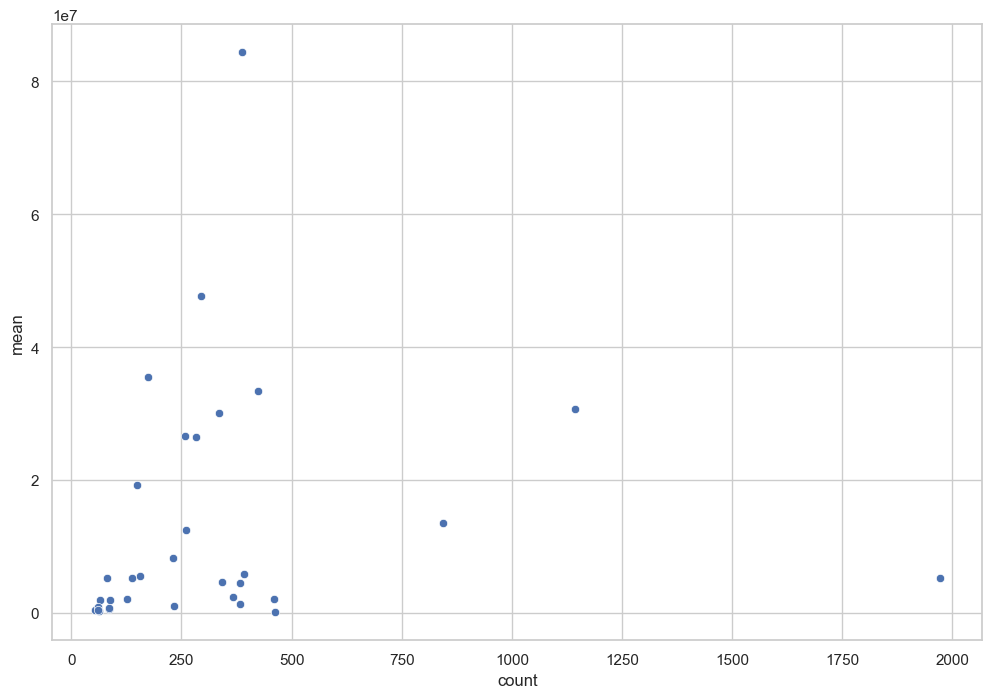

In [ ]:
# The visualization code for question #1

sns.set_theme(style = 'whitegrid')
plt.figure(figsize=(12,8))


sns.scatterplot(data=category_stats, x = 'count', y='mean')



plt.show()

